<a href="https://colab.research.google.com/github/syedalijabir/math252-project/blob/main/CompareResults.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1 mount gDrive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 2. Install R and Git tools in Colab

!apt-get update -qq
!apt-get install -y r-base git

# Install rpy2 (R bridge for Python)
!pip install -q rpy2

# Load R magic
%load_ext rpy2.ipython

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.17).
r-base is already the newest version (4.5.3-1.2204.0).
0 upgraded, 0 newly installed, 0 to remove and 60 not upgraded.


In [3]:
# 3. Clone repo into Colab

%cd /content
!git clone https://github.com/syedalijabir/math252-project.git
%cd /content/math252-project

/content
Cloning into 'math252-project'...
remote: Enumerating objects: 744, done.
remote: Counting objects: 100% (67/67), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 744 (delta 19), reused 50 (delta 11), pack-reused 677 (from 2)
Receiving objects: 100% (744/744), 2.24 GiB | 90.67 MiB/s, done.
Resolving deltas: 100% (139/139), done.
Updating files: 100% (330/330), done.
/content/math252-project


In [4]:
%%R
print("R is working!")
packages <- c(
  "readr", "dplyr", "tidyr", "stringr", "purrr",
  "ggplot2", "mclust"
)

installed <- rownames(installed.packages())
to_install <- setdiff(packages, installed)

if (length(to_install) > 0) {
  install.packages(to_install, repos = "https://cloud.r-project.org")
}

invisible(lapply(packages, library, character.only = TRUE))

set.seed(42)

[1] "R is working!"


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/mclust_6.1.2.tar.gz'
Content type 'application/x-gzip' length 2779985 bytes (2.7 MB)
downloaded 2.7 MB


The downloaded source packages are in
	‘/tmp/RtmpvrXCo1/downloaded_packages’

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

                   __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.

Attaching package: ‘mclust’

The following object is masked from ‘package:purrr’:

    map

The following object is masked from ‘package:dplyr’:

    count



In [5]:
# Define paths and output folders
%%R
base_repo <- "/content/math252-project"
drive_out <- "/content/drive/MyDrive/math252-project-colab-output"

benchmark_cache_dir <- file.path(drive_out, "output", "benchmark_cache")
fpdc_cache_dir <- file.path(drive_out, "output", "fpdc_cache")
comparison_dir <- file.path(drive_out, "output", "comparison_results")
plots_dir <- file.path(comparison_dir, "plots")

dir.create(comparison_dir, recursive = TRUE, showWarnings = FALSE)
dir.create(plots_dir, recursive = TRUE, showWarnings = FALSE)

cat("Benchmark cache:", benchmark_cache_dir, "\n")
cat("FPDC cache:", fpdc_cache_dir, "\n")
cat("Comparison output:", comparison_dir, "\n")

Benchmark cache: /content/drive/MyDrive/math252-project-colab-output/output/benchmark_cache 
FPDC cache: /content/drive/MyDrive/math252-project-colab-output/output/fpdc_cache 
Comparison output: /content/drive/MyDrive/math252-project-colab-output/output/comparison_results 


In [6]:
# Inspect a sample of files first
%%R
benchmark_files <- list.files(benchmark_cache_dir, pattern = "\\.rds$", full.names = TRUE)
fpdc_files <- list.files(fpdc_cache_dir, pattern = "\\.rds$", full.names = TRUE)

cat("Benchmark cache file count:", length(benchmark_files), "\n")
cat("FPDC cache file count:", length(fpdc_files), "\n\n")

cat("Sample benchmark files:\n")
print(head(basename(benchmark_files), 10))

cat("\nSample FPDC files:\n")
print(head(basename(fpdc_files), 10))

Benchmark cache file count: 78 
FPDC cache file count: 85 

Sample benchmark files:
 [1] "kmeans_user_embeddings_128_k2.rds" "kmeans_user_embeddings_128_k3.rds"
 [3] "kmeans_user_embeddings_128_k4.rds" "kmeans_user_embeddings_128_k5.rds"
 [5] "kmeans_user_embeddings_128_k6.rds" "kmeans_user_embeddings_128_k7.rds"
 [7] "kmeans_user_embeddings_128_k8.rds" "kmeans_user_embeddings_64_k2.rds" 
 [9] "kmeans_user_embeddings_64_k3.rds"  "kmeans_user_embeddings_64_k4.rds" 

Sample FPDC files:
 [1] "best_fpdc_user_embeddings_128_k2_nf2.rds"
 [2] "best_fpdc_user_embeddings_256_k2_nf3.rds"
 [3] "best_fpdc_user_embeddings_64_k5_nf4.rds" 
 [4] "fpdc_full_result_user_embeddings_128.rds"
 [5] "fpdc_full_result_user_embeddings_256.rds"
 [6] "fpdc_full_result_user_embeddings_64.rds" 
 [7] "fpdc_user_embeddings_128_k2_nf2_nu10.rds"
 [8] "fpdc_user_embeddings_128_k2_nf3_nu10.rds"
 [9] "fpdc_user_embeddings_128_k2_nf4_nu10.rds"
[10] "fpdc_user_embeddings_128_k2_nf5_nu10.rds"


In [7]:
# Helper functions for parsing filenames and safely extracting fields
%%R
safe_get <- function(x, nm, default = NA) {
  if (is.null(x)) return(default)
  if (!is.list(x)) return(default)
  if (nm %in% names(x)) return(x[[nm]])
  default
}

extract_labels <- function(obj, method) {
  if (is.null(obj)) return(NULL)

  # labels saved directly
  lbl <- safe_get(obj, "labels", NULL)
  if (!is.null(lbl)) return(lbl)

  # model inside object
  model <- safe_get(obj, "model", NULL)
  if (!is.null(model)) {
    if (method == "kmeans" && "cluster" %in% names(model)) return(model$cluster)
    if (method == "pd"     && "label"   %in% names(model)) return(model$label)
    if (method == "rkm"    && "cluster" %in% names(model)) return(model$cluster)
    if (method == "fpdc"   && "label"   %in% names(model)) return(model$label)
  }

  # whole object might itself be the fitted model
  if (method == "kmeans" && "cluster" %in% names(obj)) return(obj$cluster)
  if (method == "pd"     && "label"   %in% names(obj)) return(obj$label)
  if (method == "rkm"    && "cluster" %in% names(obj)) return(obj$cluster)
  if (method == "fpdc"   && "label"   %in% names(obj)) return(obj$label)

  NULL
}

extract_runtime <- function(obj) {
  rt <- safe_get(obj, "runtime_sec", NA_real_)
  if (!is.na(rt)) return(rt)
  rt <- safe_get(obj, "runtime_total_sec", NA_real_)
  rt
}

extract_silhouette <- function(obj) {
  val <- safe_get(obj, "Silhouette", NA_real_)
  if (!is.na(val)) return(val)
  val <- safe_get(obj, "avg_silhouette", NA_real_)
  if (!is.na(val)) return(val)
  val
}

extract_ch <- function(obj) {
  val <- safe_get(obj, "CH", NA_real_)
  if (!is.na(val)) return(val)
  val <- safe_get(obj, "ch", NA_real_)
  val
}

extract_probsilh <- function(obj) {
  val <- safe_get(obj, "ProbSilh", NA_real_)
  if (!is.na(val)) return(val)
  val
}

parse_benchmark_filename <- function(path) {
  f <- basename(path)

  if (grepl("^kmeans_", f)) {
    m <- stringr::str_match(f, "^kmeans_(user_embeddings_[0-9]+)_k([0-9]+)\\.rds$")
    return(data.frame(
      file = path,
      method = "KMeans",
      embedding = m[, 2],
      k = as.integer(m[, 3]),
      nf = NA_integer_,
      nu = NA_integer_,
      stringsAsFactors = FALSE
    ))
  }

  if (grepl("^pd_", f)) {
    m <- stringr::str_match(f, "^pd_(user_embeddings_[0-9]+)_k([0-9]+)\\.rds$")
    return(data.frame(
      file = path,
      method = "PD",
      embedding = m[, 2],
      k = as.integer(m[, 3]),
      nf = NA_integer_,
      nu = NA_integer_,
      stringsAsFactors = FALSE
    ))
  }

  if (grepl("^rkm_", f)) {
    m <- stringr::str_match(f, "^rkm_(user_embeddings_[0-9]+)_k([0-9]+)_nf([0-9]+)\\.rds$")
    return(data.frame(
      file = path,
      method = "RKM",
      embedding = m[, 2],
      k = as.integer(m[, 3]),
      nf = as.integer(m[, 4]),
      nu = NA_integer_,
      stringsAsFactors = FALSE
    ))
  }

  NULL
}

parse_fpdc_filename <- function(path) {
  f <- basename(path)

  # only keep per-model cache files, not full-result / best-result wrappers
  if (!grepl("^fpdc_user_embeddings_", f)) return(NULL)

  m <- stringr::str_match(
    f,
    "^fpdc_(user_embeddings_[0-9]+)_k([0-9]+)_nf([0-9]+)_nu([0-9]+)\\.rds$"
  )

  if (all(is.na(m))) return(NULL)

  data.frame(
    file = path,
    method = "FPDC",
    embedding = m[, 2],
    k = as.integer(m[, 3]),
    nf = as.integer(m[, 4]),
    nu = as.integer(m[, 5]),
    stringsAsFactors = FALSE
  )
}

In [17]:
# Load and parse all .rds files
%%R
benchmark_files <- list.files(benchmark_cache_dir, pattern = "\\.rds$", full.names = TRUE)
fpdc_files <- list.files(fpdc_cache_dir, pattern = "\\.rds$", full.names = TRUE)

benchmark_meta <- bind_rows(purrr::compact(lapply(benchmark_files, parse_benchmark_filename)))
fpdc_meta <- bind_rows(purrr::compact(lapply(fpdc_files, parse_fpdc_filename)))

all_meta <- bind_rows(benchmark_meta, fpdc_meta)

cat("Parsed model files:", nrow(all_meta), "\n")
print(head(all_meta, 10))

Parsed model files: 148 
                                                                                                           file
1  /content/drive/MyDrive/math252-project-colab-output/output/benchmark_cache/kmeans_user_embeddings_128_k2.rds
2  /content/drive/MyDrive/math252-project-colab-output/output/benchmark_cache/kmeans_user_embeddings_128_k3.rds
3  /content/drive/MyDrive/math252-project-colab-output/output/benchmark_cache/kmeans_user_embeddings_128_k4.rds
4  /content/drive/MyDrive/math252-project-colab-output/output/benchmark_cache/kmeans_user_embeddings_128_k5.rds
5  /content/drive/MyDrive/math252-project-colab-output/output/benchmark_cache/kmeans_user_embeddings_128_k6.rds
6  /content/drive/MyDrive/math252-project-colab-output/output/benchmark_cache/kmeans_user_embeddings_128_k7.rds
7  /content/drive/MyDrive/math252-project-colab-output/output/benchmark_cache/kmeans_user_embeddings_128_k8.rds
8   /content/drive/MyDrive/math252-project-colab-output/output/benchmark_cache/

In [18]:
# Read objects, extract metrics, and keep labels for ARI

%%R
read_model_record <- function(file, method, embedding, k, nf, nu) {
  obj <- tryCatch(readRDS(file), error = function(e) NULL)

  if (is.null(obj)) {
    return(list(
      metrics = data.frame(
        file = file, method = method, embedding = embedding, k = k, nf = nf, nu = nu,
        runtime_sec = NA_real_, silhouette = NA_real_, ch = NA_real_, prob_silh = NA_real_,
        n_obs = NA_integer_, status = "read_error", stringsAsFactors = FALSE
      ),
      labels = NULL
    ))
  }

  m_lower <- tolower(method)
  method_key <- switch(
    m_lower,
    "kmeans" = "kmeans",
    "pd" = "pd",
    "rkm" = "rkm",
    "fpdc" = "fpdc",
    m_lower
  )

  labels <- extract_labels(obj, method_key)
  runtime_sec <- extract_runtime(obj)
  silhouette <- extract_silhouette(obj)
  ch <- extract_ch(obj)
  prob_silh <- extract_probsilh(obj)
  n_obs <- if (is.null(labels)) NA_integer_ else length(labels)

  metrics <- data.frame(
    file = file,
    method = method,
    embedding = embedding,
    k = k,
    nf = nf,
    nu = nu,
    runtime_sec = as.numeric(runtime_sec),
    silhouette = as.numeric(silhouette),
    ch = as.numeric(ch),
    prob_silh = as.numeric(prob_silh),
    n_obs = n_obs,
    status = "ok",
    stringsAsFactors = FALSE
  )

  list(metrics = metrics, labels = labels)
}

model_records <- vector("list", nrow(all_meta))

for (i in seq_len(nrow(all_meta))) {
  row <- all_meta[i, ]
  model_records[[i]] <- read_model_record(
    file = row$file,
    method = row$method,
    embedding = row$embedding,
    k = row$k,
    nf = row$nf,
    nu = row$nu
  )
}

metrics_df <- bind_rows(lapply(model_records, `[[`, "metrics"))
labels_list <- lapply(model_records, `[[`, "labels")

metrics_df$model_id <- paste0(
  metrics_df$method, "__",
  metrics_df$embedding, "__k", metrics_df$k,
  ifelse(is.na(metrics_df$nf), "", paste0("__nf", metrics_df$nf)),
  ifelse(is.na(metrics_df$nu), "", paste0("__nu", metrics_df$nu))
)

cat("Loaded metrics rows:", nrow(metrics_df), "\n")
print(head(metrics_df, 12))

Loaded metrics rows: 148 
                                                                                                           file
1  /content/drive/MyDrive/math252-project-colab-output/output/benchmark_cache/kmeans_user_embeddings_128_k2.rds
2  /content/drive/MyDrive/math252-project-colab-output/output/benchmark_cache/kmeans_user_embeddings_128_k3.rds
3  /content/drive/MyDrive/math252-project-colab-output/output/benchmark_cache/kmeans_user_embeddings_128_k4.rds
4  /content/drive/MyDrive/math252-project-colab-output/output/benchmark_cache/kmeans_user_embeddings_128_k5.rds
5  /content/drive/MyDrive/math252-project-colab-output/output/benchmark_cache/kmeans_user_embeddings_128_k6.rds
6  /content/drive/MyDrive/math252-project-colab-output/output/benchmark_cache/kmeans_user_embeddings_128_k7.rds
7  /content/drive/MyDrive/math252-project-colab-output/output/benchmark_cache/kmeans_user_embeddings_128_k8.rds
8   /content/drive/MyDrive/math252-project-colab-output/output/benchmark_cache

In [19]:
# Save the full combined metrics table
%%R
write.csv(
  metrics_df,
  file.path(comparison_dir, "comparison_metrics_all_models.csv"),
  row.names = FALSE
)

cat("Saved:", file.path(comparison_dir, "comparison_metrics_all_models.csv"), "\n")

Saved: /content/drive/MyDrive/math252-project-colab-output/output/comparison_results/comparison_metrics_all_models.csv 


In [20]:
# Build best-model summaries and method-level summaries
%%R
valid_metrics <- metrics_df %>%
  filter(!is.na(silhouette))

best_per_method_embedding <- valid_metrics %>%
  group_by(method, embedding) %>%
  arrange(desc(silhouette), desc(ch), .by_group = TRUE) %>%
  slice(1) %>%
  ungroup()

best_per_method <- valid_metrics %>%
  group_by(method) %>%
  arrange(desc(silhouette), desc(ch), .by_group = TRUE) %>%
  slice(1) %>%
  ungroup()

method_summary <- valid_metrics %>%
  group_by(method) %>%
  summarise(
    n_models = n(),
    avg_runtime_sec = mean(runtime_sec, na.rm = TRUE),
    median_runtime_sec = median(runtime_sec, na.rm = TRUE),
    max_runtime_sec = max(runtime_sec, na.rm = TRUE),
    avg_silhouette = mean(silhouette, na.rm = TRUE),
    best_silhouette = max(silhouette, na.rm = TRUE),
    avg_ch = mean(ch, na.rm = TRUE),
    best_ch = max(ch, na.rm = TRUE),
    avg_prob_silh = mean(prob_silh, na.rm = TRUE),
    best_prob_silh = max(prob_silh, na.rm = TRUE),
    .groups = "drop"
  )

complexity_summary <- valid_metrics %>%
  mutate(
    complexity_score = ifelse(is.na(nf), k, k * nf),
    sil_per_sec = silhouette / runtime_sec
  ) %>%
  select(method, embedding, k, nf, nu, runtime_sec, silhouette, ch, prob_silh, complexity_score, sil_per_sec)

write.csv(best_per_method_embedding, file.path(comparison_dir, "best_per_method_embedding.csv"), row.names = FALSE)
write.csv(best_per_method, file.path(comparison_dir, "best_per_method.csv"), row.names = FALSE)
write.csv(method_summary, file.path(comparison_dir, "method_summary.csv"), row.names = FALSE)
write.csv(complexity_summary, file.path(comparison_dir, "complexity_summary.csv"), row.names = FALSE)

print(best_per_method_embedding)
print(method_summary)

# A tibble: 9 × 13
  file         method embedding     k    nf    nu runtime_sec silhouette      ch
  <chr>        <chr>  <chr>     <int> <int> <int>       <dbl>      <dbl>   <dbl>
1 /content/dr… FPDC   user_emb…     2     2    10    2879.      0.00688   52.8  
2 /content/dr… FPDC   user_emb…     2     3    10    2866.      0.00444   28.5  
3 /content/dr… FPDC   user_emb…     5     4    10      53.9     0.0123    32.1  
4 /content/dr… KMeans user_emb…     2    NA    NA       0.862   0.334    140.   
5 /content/dr… KMeans user_emb…     2    NA    NA       0.995   0.214    132.   
6 /content/dr… PD     user_emb…     2    NA    NA       0.184  -0.000100   0.920
7 /content/dr… PD     user_emb…     2    NA    NA       0.287   0.00277   10.1  
8 /content/dr… RKM    user_emb…     2     4    NA     184.      0.331    140.   
9 /content/dr… RKM    user_emb…     2     2    NA     279.      0.235    132.   
# ℹ 4 more variables: prob_silh <dbl>, n_obs <int>, status <chr>,
#   model_id <chr>
# A t

In addition: Warning message:
There were 2 warnings in `summarise()`.
The first warning was:
ℹ In argument: `best_prob_silh = max(prob_silh, na.rm = TRUE)`.
ℹ In group 2: `method = "KMeans"`.
Caused by warning in `max()`:
! no non-missing arguments to max; returning -Inf
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning. 


In [21]:
# Compute ARI comparisons for same embedding and same k
%%R
get_labels_by_model_id <- function(model_id) {
  idx <- match(model_id, metrics_df$model_id)
  if (is.na(idx)) return(NULL)
  labels_list[[idx]]
}

ari_rows <- list()
ctr <- 1

for (emb in unique(metrics_df$embedding)) {
  for (k_val in sort(unique(metrics_df$k))) {

    subset_df <- metrics_df %>%
      filter(embedding == emb, k == k_val, !is.na(n_obs), status == "ok")

    if (nrow(subset_df) < 2) next

    for (i in seq_len(nrow(subset_df) - 1)) {
      for (j in (i + 1):nrow(subset_df)) {

        row_i <- subset_df[i, ]
        row_j <- subset_df[j, ]

        lbl_i <- get_labels_by_model_id(row_i$model_id)
        lbl_j <- get_labels_by_model_id(row_j$model_id)

        if (is.null(lbl_i) || is.null(lbl_j)) next
        if (length(lbl_i) != length(lbl_j)) next

        ari_val <- tryCatch(
          mclust::adjustedRandIndex(lbl_i, lbl_j),
          error = function(e) NA_real_
        )

        ari_rows[[ctr]] <- data.frame(
          embedding = emb,
          k = k_val,
          method_1 = row_i$method,
          method_2 = row_j$method,
          nf_1 = row_i$nf,
          nf_2 = row_j$nf,
          nu_1 = row_i$nu,
          nu_2 = row_j$nu,
          ari = ari_val,
          stringsAsFactors = FALSE
        )
        ctr <- ctr + 1
      }
    }
  }
}

ari_df <- bind_rows(ari_rows)

write.csv(
  ari_df,
  file.path(comparison_dir, "ari_pairwise_same_embedding_same_k.csv"),
  row.names = FALSE
)

cat("ARI comparisons:", nrow(ari_df), "\n")
print(head(ari_df, 20))

ARI comparisons: 533 
             embedding k method_1 method_2 nf_1 nf_2 nu_1 nu_2           ari
1  user_embeddings_128 2   KMeans       PD   NA   NA   NA   NA -1.373693e-04
2  user_embeddings_128 2   KMeans      RKM   NA    2   NA   NA  9.864524e-01
3  user_embeddings_128 2   KMeans      RKM   NA    3   NA   NA  9.864524e-01
4  user_embeddings_128 2   KMeans      RKM   NA    4   NA   NA  9.876734e-01
5  user_embeddings_128 2   KMeans      RKM   NA    5   NA   NA  9.852335e-01
6  user_embeddings_128 2   KMeans     FPDC   NA    2   NA   10  9.093575e-03
7  user_embeddings_128 2   KMeans     FPDC   NA    3   NA   10  2.681361e-03
8  user_embeddings_128 2   KMeans     FPDC   NA    4   NA   10  1.058663e-03
9  user_embeddings_128 2   KMeans     FPDC   NA    5   NA   10 -2.106748e-05
10 user_embeddings_128 2       PD      RKM   NA    2   NA   NA -1.741353e-04
11 user_embeddings_128 2       PD      RKM   NA    3   NA   NA -1.741353e-04
12 user_embeddings_128 2       PD      RKM   NA    4  

In [41]:
# Create a cleaner ARI summary by method pair
%%R
if (nrow(ari_df) > 0) {
  ari_summary <- ari_df %>%
    mutate(
      method_pair = paste(pmin(method_1, method_2), pmax(method_1, method_2), sep = "_vs_")
    ) %>%
    group_by(method_pair) %>%
    summarise(
      n_comparisons = n(),
      avg_ari = mean(ari, na.rm = TRUE),
      median_ari = median(ari, na.rm = TRUE),
      max_ari = max(ari, na.rm = TRUE),
      min_ari = min(ari, na.rm = TRUE),
      .groups = "drop"
    ) %>%
    arrange(desc(avg_ari))

  write.csv(
    ari_summary,
    file.path(comparison_dir, "ari_summary_by_method_pair.csv"),
    row.names = FALSE
  )

  print(ari_summary)
}

# A tibble: 8 × 6
  method_pair    n_comparisons  avg_ari median_ari max_ari    min_ari
  <chr>                  <int>    <dbl>      <dbl>   <dbl>      <dbl>
1 RKM_vs_RKM                60 0.665      0.737    1        0.151    
2 KMeans_vs_RKM             41 0.594      0.529    0.988    0.182    
3 FPDC_vs_FPDC             111 0.225      0.208    0.745    0.000888 
4 FPDC_vs_RKM              160 0.0633     0.0464   0.286   -0.0000545
5 FPDC_vs_KMeans            53 0.0524     0.0415   0.246   -0.0000211
6 FPDC_vs_PD                53 0.00882    0.00419  0.0476  -0.000222 
7 PD_vs_RKM                 41 0.00151    0.000191 0.0145  -0.000982 
8 KMeans_vs_PD              14 0.000792   0.000118 0.00472 -0.000789 


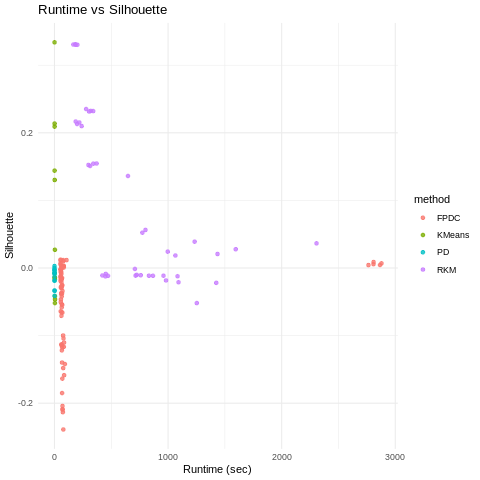

In [42]:
# Make report-friendly plots
%%R
theme_set(theme_minimal())

# Runtime by method
p_runtime <- ggplot(valid_metrics, aes(x = method, y = runtime_sec)) +
  geom_boxplot() +
  labs(title = "Runtime by Method", x = "Method", y = "Runtime (sec)")

ggsave(file.path(plots_dir, "runtime_by_method.png"), p_runtime, width = 8, height = 5, dpi = 120)

# Silhouette by method
p_sil <- ggplot(valid_metrics, aes(x = method, y = silhouette)) +
  geom_boxplot() +
  labs(title = "Silhouette by Method", x = "Method", y = "Silhouette")

ggsave(file.path(plots_dir, "silhouette_by_method.png"), p_sil, width = 8, height = 5, dpi = 120)

# CH by method
p_ch <- ggplot(valid_metrics, aes(x = method, y = ch)) +
  geom_boxplot() +
  labs(title = "Calinski-Harabasz by Method", x = "Method", y = "CH")

ggsave(file.path(plots_dir, "ch_by_method.png"), p_ch, width = 8, height = 5, dpi = 120)

# Probability silhouette by method where available
p_prob <- ggplot(valid_metrics %>% filter(!is.na(prob_silh)), aes(x = method, y = prob_silh)) +
  geom_boxplot() +
  labs(title = "Probability Silhouette by Method", x = "Method", y = "Probability Silhouette")

ggsave(file.path(plots_dir, "prob_silh_by_method.png"), p_prob, width = 8, height = 5, dpi = 120)

# Complexity vs performance
p_complex <- ggplot(complexity_summary, aes(x = complexity_score, y = silhouette, color = method)) +
  geom_point(alpha = 0.8) +
  labs(title = "Complexity vs Silhouette", x = "Complexity Score", y = "Silhouette")

ggsave(file.path(plots_dir, "complexity_vs_silhouette.png"), p_complex, width = 8, height = 5, dpi = 120)

# Runtime vs silhouette
p_tradeoff <- ggplot(complexity_summary, aes(x = runtime_sec, y = silhouette, color = method)) +
  geom_point(alpha = 0.8) +
  labs(title = "Runtime vs Silhouette", x = "Runtime (sec)", y = "Silhouette")

ggsave(file.path(plots_dir, "runtime_vs_silhouette.png"), p_tradeoff, width = 8, height = 5, dpi = 120)

print(p_runtime)
print(p_sil)
print(p_ch)
print(p_prob)
print(p_complex)
print(p_tradeoff)

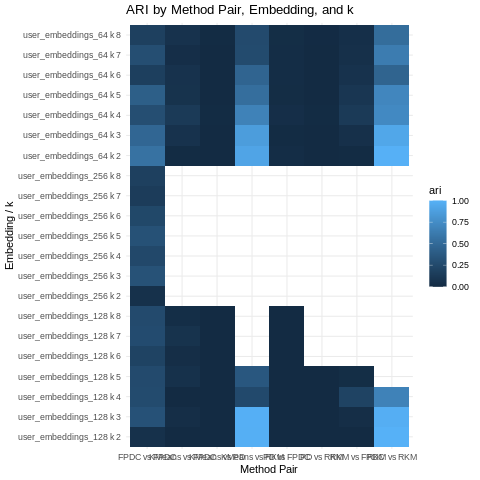

In [43]:
# ARI heatmap-style plot
%%R
if (nrow(ari_df) > 0) {
  ari_plot_df <- ari_df %>%
    mutate(
      method_pair = paste(method_1, "vs", method_2),
      emb_k = paste(embedding, "k", k)
    )

  p_ari <- ggplot(ari_plot_df, aes(x = method_pair, y = emb_k, fill = ari)) +
    geom_tile() +
    labs(title = "ARI by Method Pair, Embedding, and k", x = "Method Pair", y = "Embedding / k")

  ggsave(file.path(plots_dir, "ari_heatmap.png"), p_ari, width = 10, height = 7, dpi = 120)
  print(p_ari)
}

In [93]:
# Final concise summary of findings
%%R
cat("========================================\n")
cat("COMPARISON SUMMARY\n")
cat("========================================\n\n")

cat("Best model per method and embedding:\n")
print(best_per_method_embedding)

cat("\nMethod-level summary:\n")
print(method_summary)

if (exists("ari_summary")) {
  cat("\nAverage ARI by method pair:\n")
  print(ari_summary)
}

best_overall <- valid_metrics %>%
  arrange(desc(silhouette), desc(ch)) %>%
  slice(1)

cat("\nTop model by silhouette overall:\n")
print(best_overall)

#* Interpretation notes:
#* -Compare methods primarily by silhouette, then CH as secondary support.
#* - Use probability silhouette only for PD/FPDC where available.
#* - Use ARI to assess whether methods agree on the same embedding and k.
#* - Use runtime and complexity-vs-performance to assess whether more complex methods are justified.
#* - If complex methods show only tiny silhouette gains but much larger runtime, that argues against the added complexity.\n")

cat("\nSaved outputs to:\n")
cat(comparison_dir, "\n")

COMPARISON SUMMARY

Best model per method and embedding:
# A tibble: 9 × 13
  file         method embedding     k    nf    nu runtime_sec silhouette      ch
  <chr>        <chr>  <chr>     <int> <int> <int>       <dbl>      <dbl>   <dbl>
1 /content/dr… FPDC   user_emb…     2     2    10    2879.      0.00688   52.8  
2 /content/dr… FPDC   user_emb…     2     3    10    2866.      0.00444   28.5  
3 /content/dr… FPDC   user_emb…     5     4    10      53.9     0.0123    32.1  
4 /content/dr… KMeans user_emb…     2    NA    NA       0.862   0.334    140.   
5 /content/dr… KMeans user_emb…     2    NA    NA       0.995   0.214    132.   
6 /content/dr… PD     user_emb…     2    NA    NA       0.184  -0.000100   0.920
7 /content/dr… PD     user_emb…     2    NA    NA       0.287   0.00277   10.1  
8 /content/dr… RKM    user_emb…     2     4    NA     184.      0.331    140.   
9 /content/dr… RKM    user_emb…     2     2    NA     279.      0.235    132.   
# ℹ 4 more variables: prob_silh <

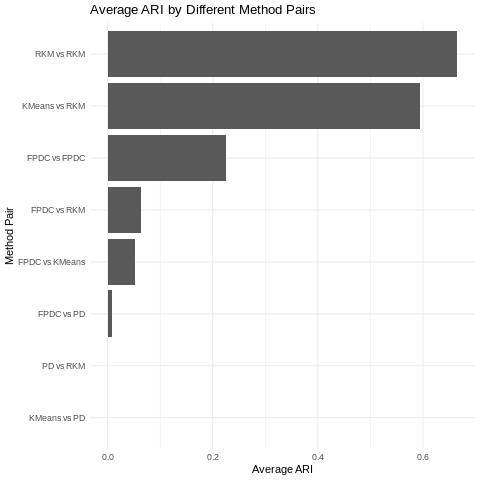

In [94]:
%%R
library(dplyr)
library(ggplot2)

# Use existing ari_df
ari_plot_df <- ari_df %>%
  mutate(
    method_pair = paste(pmin(method_1, method_2),
                        pmax(method_1, method_2),
                        sep = " vs ")
  ) %>%
  group_by(method_pair) %>%
  summarise(
    avg_ari = mean(ari, na.rm = TRUE),
    max_ari = max(ari, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(avg_ari))

# Plot
p_ari_bar <- ggplot(ari_plot_df, aes(x = reorder(method_pair, avg_ari), y = avg_ari)) +
  geom_col() +
  coord_flip() +
  theme_minimal() +
  labs(
    title = "Average ARI by Different Method Pairs",
    x = "Method Pair",
    y = "Average ARI"
  )

print(p_ari_bar)

ggsave(
  filename = file.path(plots_dir, "ari_barplot.png"),
  plot = p_ari_bar,
  width = 8,
  height = 5,
  dpi = 120
)

In [72]:
%%R
library(dplyr)
library(ggplot2)

ari_plot_df <- ari_df %>%
  filter(method_1 != method_2) %>%
  mutate(
    method_pair = paste(
      pmin(method_1, method_2),
      pmax(method_1, method_2),
      sep = " vs "
    )
  ) %>%
  group_by(method_pair) %>%
  summarise(
    avg_ari = mean(ari, na.rm = TRUE),
    max_ari = max(ari, na.rm = TRUE),
    n_comparisons = n(),
    .groups = "drop"
  ) %>%
  arrange(desc(avg_ari))

  print(ari_plot_df)


# A tibble: 6 × 4
  method_pair     avg_ari max_ari n_comparisons
  <chr>             <dbl>   <dbl>         <int>
1 KMeans vs RKM  0.594    0.988              41
2 FPDC vs RKM    0.0633   0.286             160
3 FPDC vs KMeans 0.0524   0.246              53
4 FPDC vs PD     0.00882  0.0476             53
5 PD vs RKM      0.00151  0.0145             41
6 KMeans vs PD   0.000792 0.00472            14


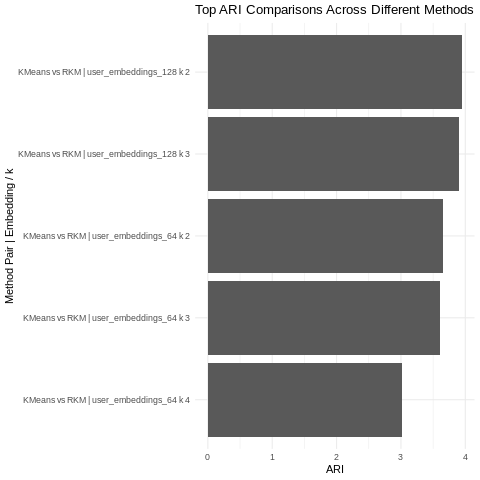

In [95]:
%%R
library(dplyr)
library(ggplot2)

top_ari <- ari_df %>%
  filter(method_1 != method_2) %>%
  mutate(
    method_pair = paste(
      pmin(method_1, method_2),
      pmax(method_1, method_2),
      sep = " vs "
    ),
    emb_k = paste(embedding, "k", k)
  ) %>%
  arrange(desc(ari)) %>%
  slice(1:20)

p_top_ari <- ggplot(top_ari, aes(x = reorder(paste(method_pair, emb_k, sep = " | "), ari), y = ari)) +
  geom_col() +
  coord_flip() +
  theme_minimal() +
  labs(
    title = "Top ARI Comparisons Across Different Methods",
    x = "Method Pair | Embedding / k",
    y = "ARI"
  )

print(p_top_ari)

ggsave(
  filename = file.path(plots_dir, "top_ari_diff_methods_only.png"),
  plot = p_top_ari,
  width = 10,
  height = 7,
  dpi = 120
)

In [74]:
%%R
ari_summary_diff <- ari_df %>%
  filter(method_1 != method_2) %>%
  mutate(
    method_pair = paste(
      pmin(method_1, method_2),
      pmax(method_1, method_2),
      sep = "_vs_"
    )
  ) %>%
  group_by(method_pair) %>%
  summarise(
    n_comparisons = n(),
    avg_ari = mean(ari, na.rm = TRUE),
    median_ari = median(ari, na.rm = TRUE),
    max_ari = max(ari, na.rm = TRUE),
    min_ari = min(ari, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(avg_ari))

print(ari_summary_diff)

# A tibble: 6 × 6
  method_pair    n_comparisons  avg_ari median_ari max_ari    min_ari
  <chr>                  <int>    <dbl>      <dbl>   <dbl>      <dbl>
1 KMeans_vs_RKM             41 0.594      0.529    0.988    0.182    
2 FPDC_vs_RKM              160 0.0633     0.0464   0.286   -0.0000545
3 FPDC_vs_KMeans            53 0.0524     0.0415   0.246   -0.0000211
4 FPDC_vs_PD                53 0.00882    0.00419  0.0476  -0.000222 
5 PD_vs_RKM                 41 0.00151    0.000191 0.0145  -0.000982 
6 KMeans_vs_PD              14 0.000792   0.000118 0.00472 -0.000789 


In [75]:
%%R
library(dplyr)
library(stringr)

ari_summary_report <- ari_df %>%
  filter(method_1 != method_2) %>%

  # Standardize method pair naming
  mutate(
    method_pair = paste(
      pmin(method_1, method_2),
      pmax(method_1, method_2),
      sep = " vs "
    )
  ) %>%

  group_by(method_pair) %>%
  summarise(
    Comparisons = n(),
    Avg_ARI = mean(ari, na.rm = TRUE),
    Median_ARI = median(ari, na.rm = TRUE),
    Max_ARI = max(ari, na.rm = TRUE),
    Min_ARI = min(ari, na.rm = TRUE),
    .groups = "drop"
  ) %>%

  # Round for readability
  mutate(
    Avg_ARI = round(Avg_ARI, 3),
    Median_ARI = round(Median_ARI, 3),
    Max_ARI = round(Max_ARI, 3),
    Min_ARI = round(Min_ARI, 3)
  ) %>%

  arrange(desc(Avg_ARI))

print(ari_summary_report)



# A tibble: 6 × 6
  method_pair    Comparisons Avg_ARI Median_ARI Max_ARI Min_ARI
  <chr>                <int>   <dbl>      <dbl>   <dbl>   <dbl>
1 KMeans vs RKM           41   0.594      0.529   0.988   0.182
2 FPDC vs RKM            160   0.063      0.046   0.286   0    
3 FPDC vs KMeans          53   0.052      0.042   0.246   0    
4 FPDC vs PD              53   0.009      0.004   0.048   0    
5 PD vs RKM               41   0.002      0       0.015  -0.001
6 KMeans vs PD            14   0.001      0       0.005  -0.001


In [76]:
%%R
write.csv(
  ari_summary_report,
  file.path(comparison_dir, "ari_summary_report.csv"),
  row.names = FALSE
)

# DATAFRAME

In [108]:
# Build an easy ready-to-plot dataframe
%%R
library(dplyr)
library(stringr)
library(readr)

# Start from metrics_df if already created it earlier
plot_df <- metrics_df %>%
  mutate(
    embedding_dim = as.integer(str_extract(embedding, "[0-9]+")),
    method = factor(method, levels = c("KMeans", "PD", "RKM", "FPDC"))
  ) %>%
  select(
    method,
    embedding,
    embedding_dim,
    k,
    nf,
    nu,
    runtime_sec,
    silhouette,
    ch,
    prob_silh,
    n_obs,
    status,
    model_id
  ) %>%
  arrange(method, embedding_dim, k, nf, nu)

print(head(plot_df))

# Save it
write.csv(
  plot_df,
  file.path(comparison_dir, "plot_ready_metrics.csv"),
  row.names = FALSE
)

cat("Saved plot-ready dataframe to:\n")
cat(file.path(comparison_dir, "plot_ready_metrics.csv"), "\n")

# create method-specific plotting dataframes
kmeans_plot_df <- plot_df %>%
  filter(method == "KMeans")

pd_plot_df <- plot_df %>%
  filter(method == "PD")

rkm_plot_df <- plot_df %>%
  filter(method == "RKM")

fpdc_plot_df <- plot_df %>%
  filter(method == "FPDC")

cat("KMeans rows:", nrow(kmeans_plot_df), "\n")
cat("PD rows:", nrow(pd_plot_df), "\n")
cat("RKM rows:", nrow(rkm_plot_df), "\n")
cat("FPDC rows:", nrow(fpdc_plot_df), "\n")

# best per method per embedding
best_plot_df <- plot_df %>%
  filter(!is.na(silhouette)) %>%
  group_by(method, embedding, embedding_dim) %>%
  arrange(desc(silhouette), desc(ch), .by_group = TRUE) %>%
  slice(1) %>%
  ungroup()

print(best_plot_df)

write.csv(
  best_plot_df,
  file.path(comparison_dir, "plot_ready_best_models.csv"),
  row.names = FALSE
)

# simple complexity score
plot_df <- plot_df %>%
  mutate(
    complexity_score = case_when(
      method %in% c("KMeans", "PD") ~ k,
      method %in% c("RKM", "FPDC") & !is.na(nf) ~ k * nf,
      TRUE ~ NA_real_
    )
  )

print(plot_df %>% select(method, embedding, k, nf, nu, complexity_score, silhouette, runtime_sec) %>% head(20))

  method          embedding embedding_dim k nf nu runtime_sec  silhouette
1 KMeans user_embeddings_64            64 2 NA NA   0.9951243  0.21363222
2 KMeans user_embeddings_64            64 3 NA NA   1.1123340  0.14399609
3 KMeans user_embeddings_64            64 4 NA NA   1.9527698 -0.00776121
4 KMeans user_embeddings_64            64 5 NA NA   2.4026067 -0.01432132
5 KMeans user_embeddings_64            64 6 NA NA   3.0459085 -0.01445845
6 KMeans user_embeddings_64            64 7 NA NA   3.8491256 -0.04173959
         ch prob_silh n_obs status                       model_id
1 132.23191        NA  6040     ok KMeans__user_embeddings_64__k2
2 111.42645        NA  6040     ok KMeans__user_embeddings_64__k3
3  96.93577        NA  6040     ok KMeans__user_embeddings_64__k4
4  84.82933        NA  6040     ok KMeans__user_embeddings_64__k5
5  76.32991        NA  6040     ok KMeans__user_embeddings_64__k6
6  70.18286        NA  6040     ok KMeans__user_embeddings_64__k7
Saved plot-ready dat

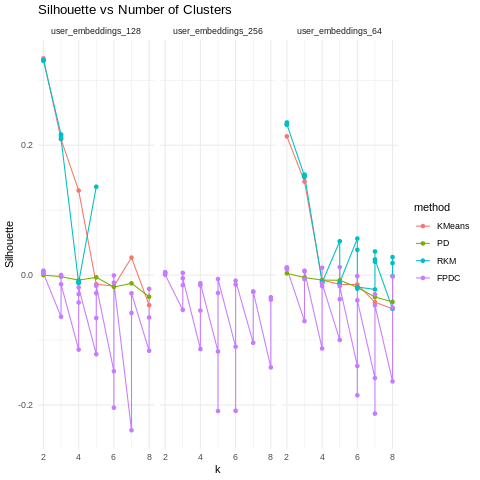

In [78]:
# Silhouette vs k
%%R
library(ggplot2)

ggplot(plot_df, aes(x = k, y = silhouette, color = method)) +
  geom_line() +
  geom_point() +
  facet_wrap(~ embedding) +
  theme_minimal() +
  labs(
    title = "Silhouette vs Number of Clusters",
    x = "k",
    y = "Silhouette"
  )



In [79]:
%%R
library(dplyr)

cat("Number of models:\n")
print(nrow(plot_df))

cat("\nMethods:\n")
print(unique(plot_df$method))

cat("\nEmbeddings:\n")
print(unique(plot_df$embedding))

cat("\nSummary stats:\n")
print(summary(plot_df))

Number of models:
[1] 148

Methods:
[1] KMeans PD     RKM    FPDC  
Levels: KMeans PD RKM FPDC

Embeddings:
[1] "user_embeddings_64"  "user_embeddings_128" "user_embeddings_256"

Summary stats:
    method    embedding         embedding_dim         k              nf       
 KMeans:14   Length:148         Min.   : 64.0   Min.   :2.00   Min.   :2.000  
 PD    :14   Class :character   1st Qu.: 64.0   1st Qu.:3.00   1st Qu.:2.000  
 RKM   :41   Mode  :character   Median :128.0   Median :5.00   Median :4.000  
 FPDC  :79                      Mean   :120.6   Mean   :4.75   Mean   :3.517  
                                3rd Qu.:128.0   3rd Qu.:6.00   3rd Qu.:5.000  
                                Max.   :256.0   Max.   :8.00   Max.   :5.000  
                                                               NA's   :28     
       nu      runtime_sec          silhouette              ch        
 Min.   :10   Min.   :   0.1842   Min.   :-0.238904   Min.   :  0.92  
 1st Qu.:10   1st Qu.:  55.1343 

Exploratory Analysis: Distribution of metrics

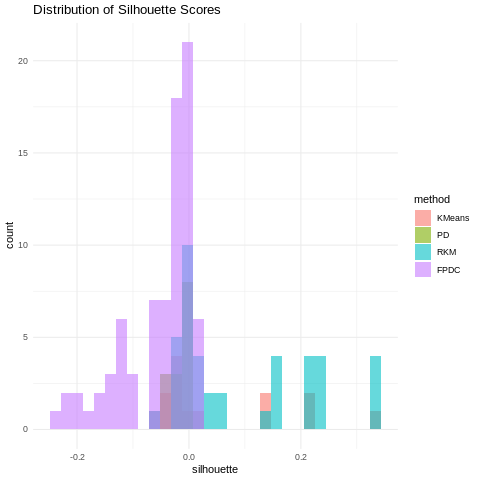

In [80]:
%%R
library(ggplot2)

ggplot(plot_df, aes(x = silhouette, fill = method)) +
  geom_histogram(bins = 30, alpha = 0.6, position = "identity") +
  theme_minimal() +
  labs(title = "Distribution of Silhouette Scores")

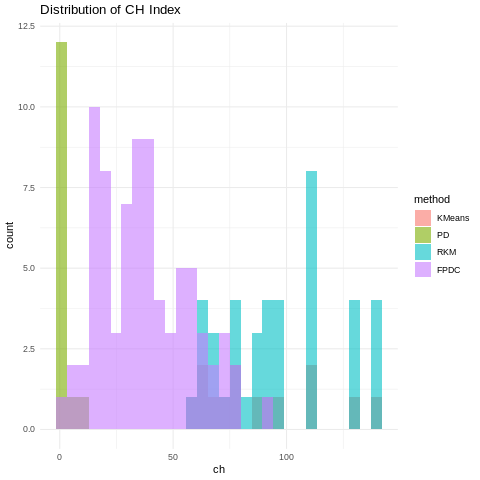

In [81]:
%%R
ggplot(plot_df, aes(x = ch, fill = method)) +
  geom_histogram(bins = 30, alpha = 0.6, position = "identity") +
  theme_minimal() +
  labs(title = "Distribution of CH Index")

In [82]:
# Method comparison summary
%%R
method_summary <- plot_df %>%
  group_by(method) %>%
  summarise(
    n = n(),
    avg_sil = mean(silhouette, na.rm = TRUE),
    best_sil = max(silhouette, na.rm = TRUE),
    avg_ch = mean(ch, na.rm = TRUE),
    best_ch = max(ch, na.rm = TRUE),
    avg_runtime = mean(runtime_sec, na.rm = TRUE),
    max_runtime = max(runtime_sec, na.rm = TRUE)
  ) %>%
  arrange(desc(avg_sil))

print(method_summary)

# A tibble: 4 × 8
  method     n avg_sil best_sil avg_ch best_ch avg_runtime max_runtime
  <fct>  <int>   <dbl>    <dbl>  <dbl>   <dbl>       <dbl>       <dbl>
1 RKM       41  0.0950  0.331    96.9    140.      688.        2307.  
2 KMeans    14  0.0607  0.334    89.3    140.        2.61         4.81
3 PD        14 -0.0135  0.00277   2.42    10.1       0.607        1.13
4 FPDC      79 -0.0512  0.0123   37.3     91.3     240.        2879.  


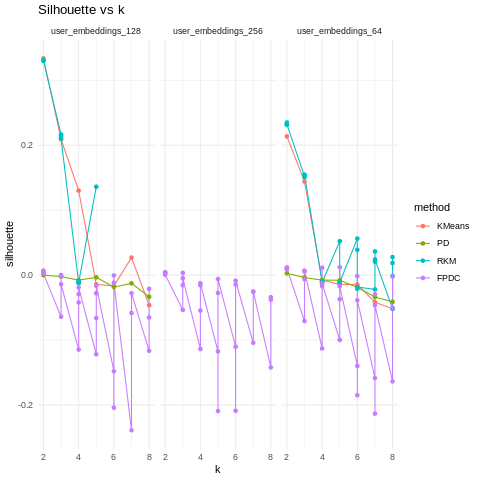

In [83]:
# Silhouette vs k
%%R
ggplot(plot_df, aes(x = k, y = silhouette, color = method)) +
  geom_line() +
  geom_point() +
  facet_wrap(~embedding) +
  theme_minimal() +
  labs(title = "Silhouette vs k")

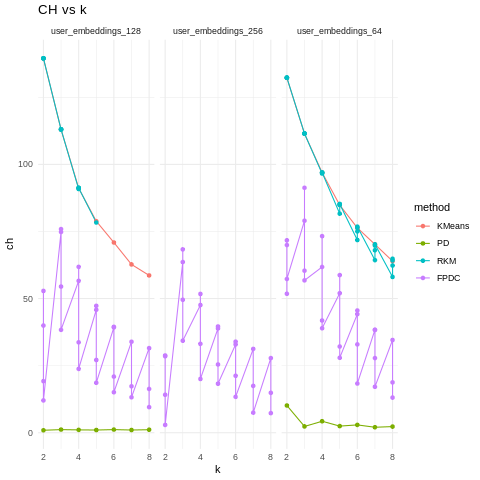

In [84]:
# CH vs k
%%R
ggplot(plot_df, aes(x = k, y = ch, color = method)) +
  geom_line() +
  geom_point() +
  facet_wrap(~embedding) +
  theme_minimal() +
  labs(title = "CH vs k")

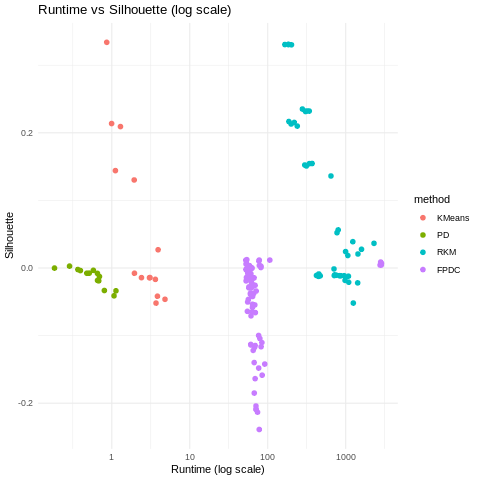

In [85]:
# Runtime vs performance
%%R
ggplot(plot_df, aes(x = runtime_sec, y = silhouette, color = method)) +
  geom_point(size = 2) +
  scale_x_log10() +
  theme_minimal() +
  labs(
    title = "Runtime vs Silhouette (log scale)",
    x = "Runtime (log scale)",
    y = "Silhouette"
  )

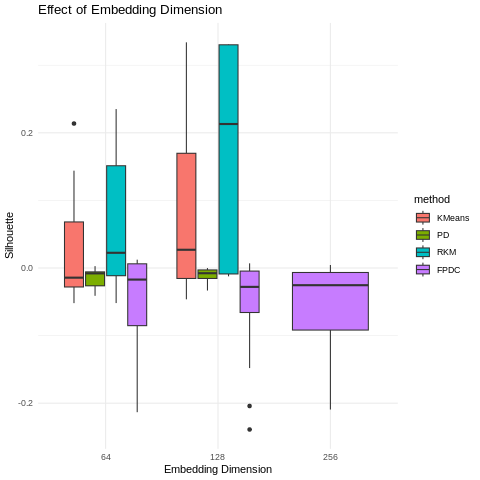

In [86]:
# Effect of embedding dimension
%%R
ggplot(plot_df, aes(x = factor(embedding_dim), y = silhouette, fill = method)) +
  geom_boxplot() +
  theme_minimal() +
  labs(
    title = "Effect of Embedding Dimension",
    x = "Embedding Dimension",
    y = "Silhouette"
  )

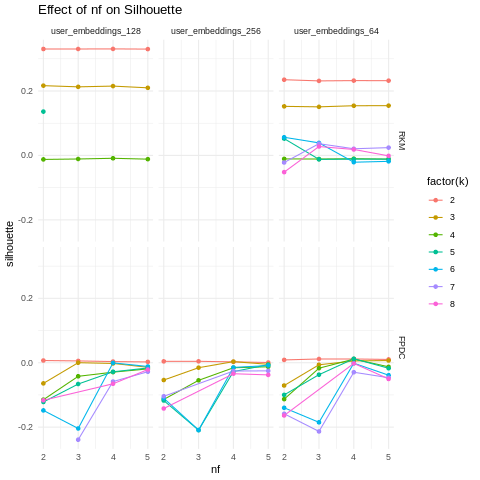

In [87]:
# Effect of nf (RKM + FPDC)
# Shows if subspace dimension matters (doesn't seem to based on plot)
%%R
ggplot(plot_df %>% filter(method %in% c("RKM", "FPDC")),
       aes(x = nf, y = silhouette, color = factor(k))) +
  geom_line() +
  geom_point() +
  facet_grid(method ~ embedding) +
  theme_minimal() +
  labs(title = "Effect of nf on Silhouette")

In [88]:
# Identify best models
%%R
best_models <- plot_df %>%
  group_by(method, embedding) %>%
  arrange(desc(silhouette), desc(ch), .by_group = TRUE) %>%
  slice(1) %>%
  ungroup()

print(best_models)

# A tibble: 9 × 14
  method embedding        embedding_dim     k    nf    nu runtime_sec silhouette
  <fct>  <chr>                    <int> <int> <int> <int>       <dbl>      <dbl>
1 KMeans user_embeddings…           128     2    NA    NA       0.862   0.334   
2 KMeans user_embeddings…            64     2    NA    NA       0.995   0.214   
3 PD     user_embeddings…           128     2    NA    NA       0.184  -0.000100
4 PD     user_embeddings…            64     2    NA    NA       0.287   0.00277 
5 RKM    user_embeddings…           128     2     4    NA     184.      0.331   
6 RKM    user_embeddings…            64     2     2    NA     279.      0.235   
7 FPDC   user_embeddings…           128     2     2    10    2879.      0.00688 
8 FPDC   user_embeddings…           256     2     3    10    2866.      0.00444 
9 FPDC   user_embeddings…            64     5     4    10      53.9     0.0123  
# ℹ 6 more variables: ch <dbl>, prob_silh <dbl>, n_obs <int>, status <chr>,
#   model_id <

In [89]:
# Check stability (variance by method)
%%R
stability <- plot_df %>%
  group_by(method) %>%
  summarise(
    sil_sd = sd(silhouette, na.rm = TRUE),
    ch_sd = sd(ch, na.rm = TRUE)
  )

print(stability)

# A tibble: 4 × 3
  method sil_sd ch_sd
  <fct>   <dbl> <dbl>
1 KMeans 0.123  26.0 
2 PD     0.0138  2.42
3 RKM    0.122  25.2 
4 FPDC   0.0656 19.9 


In [90]:
# outlier detection (bad runs silhouette < -.1)
%%R
bad_models <- plot_df %>%
  filter(silhouette < -0.1 | is.na(silhouette))

print(bad_models)

   method           embedding embedding_dim k nf nu runtime_sec silhouette
1    FPDC  user_embeddings_64            64 4  2 10    60.65769 -0.1130516
2    FPDC  user_embeddings_64            64 6  2 10    67.05261 -0.1399225
3    FPDC  user_embeddings_64            64 6  3 10    67.19953 -0.1850244
4    FPDC  user_embeddings_64            64 7  2 10    84.85019 -0.1585577
5    FPDC  user_embeddings_64            64 7  3 10    74.01934 -0.2133040
6    FPDC  user_embeddings_64            64 8  2 10    68.98094 -0.1637072
7    FPDC user_embeddings_128           128 4  2 10    69.07629 -0.1147222
8    FPDC user_embeddings_128           128 5  2 10    65.14936 -0.1218890
9    FPDC user_embeddings_128           128 6  2 10    76.54230 -0.1480547
10   FPDC user_embeddings_128           128 6  3 10    70.59980 -0.2041404
11   FPDC user_embeddings_128           128 7  3 10    77.79841 -0.2389037
12   FPDC user_embeddings_128           128 8  2 10    82.24542 -0.1165018
13   FPDC user_embeddings

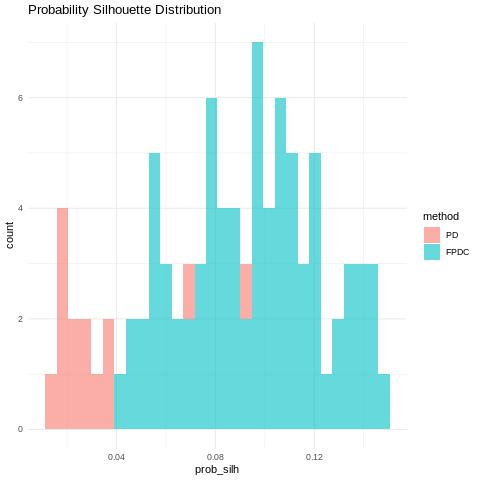

In [91]:
# Probability silhouette (FPDC/PD only)
%%R
ggplot(plot_df %>% filter(!is.na(prob_silh)),
       aes(x = prob_silh, fill = method)) +
  geom_histogram(bins = 30, alpha = 0.6) +
  theme_minimal() +
  labs(title = "Probability Silhouette Distribution")

# FOR REPORT

In [96]:
# Setup: theme, labels, and save folder
%%R
library(dplyr)
library(ggplot2)
library(scales)

final_fig_dir <- file.path(comparison_dir, "final_report_figures")
dir.create(final_fig_dir, recursive = TRUE, showWarnings = FALSE)

plot_df_pub <- plot_df %>%
  mutate(
    method = factor(method, levels = c("KMeans", "RKM", "FPDC", "PD")),
    embedding_label = factor(
      embedding_dim,
      levels = c(64, 128, 256),
      labels = c("64-dimensional", "128-dimensional", "256-dimensional")
    )
  )

theme_report <- function() {
  theme_minimal(base_size = 12) +
    theme(
      plot.title = element_text(face = "bold", size = 13, hjust = 0.5),
      plot.subtitle = element_text(size = 10, hjust = 0.5),
      axis.title = element_text(face = "bold"),
      strip.text = element_text(face = "bold"),
      legend.title = element_text(face = "bold"),
      panel.grid.minor = element_blank(),
      panel.grid.major.x = element_blank(),
      plot.margin = margin(10, 12, 10, 12)
    )
}


Attaching package: ‘scales’

The following object is masked from ‘package:purrr’:

    discard

The following object is masked from ‘package:readr’:

    col_factor



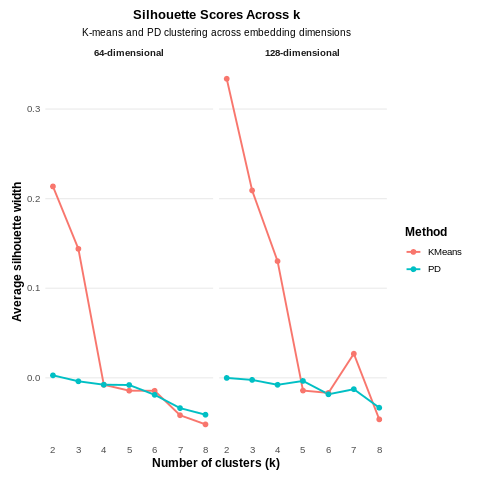

In [97]:
# Figure 1: Silhouette vs k by method and embedding
# Could be main model-selection figure.
%%R
fig1_df <- plot_df_pub %>%
  filter(method %in% c("KMeans", "PD")) %>%
  select(method, embedding_label, k, silhouette)

p1 <- ggplot(fig1_df, aes(x = k, y = silhouette, color = method, group = method)) +
  geom_line(linewidth = 0.9) +
  geom_point(size = 2) +
  facet_wrap(~ embedding_label, nrow = 1) +
  scale_x_continuous(breaks = sort(unique(fig1_df$k))) +
  labs(
    title = "Silhouette Scores Across k",
    subtitle = "K-means and PD clustering across embedding dimensions",
    x = "Number of clusters (k)",
    y = "Average silhouette width",
    color = "Method"
  ) +
  theme_report()

print(p1)

ggsave(
  file.path(final_fig_dir, "figure1_silhouette_vs_k_kmeans_pd.png"),
  p1, width = 10, height = 4.8, dpi = 300
)

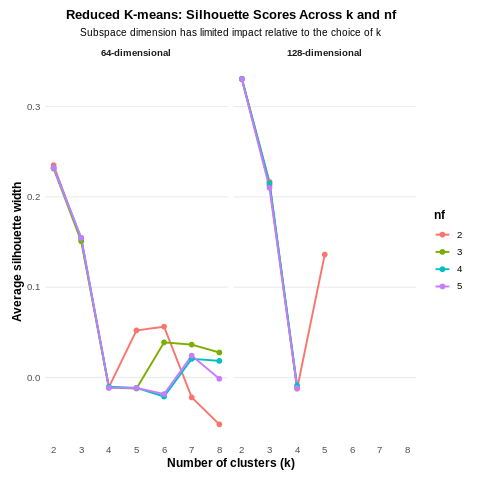

In [98]:
# Figure 2: RKM silhouette vs k, colored by nf - shows whether the added subspace dimension helps.
%%R
fig2_df <- plot_df_pub %>%
  filter(method == "RKM")

p2 <- ggplot(fig2_df, aes(x = k, y = silhouette, color = factor(nf), group = nf)) +
  geom_line(linewidth = 0.9) +
  geom_point(size = 2) +
  facet_wrap(~ embedding_label, nrow = 1) +
  scale_x_continuous(breaks = sort(unique(fig2_df$k))) +
  labs(
    title = "Reduced K-means: Silhouette Scores Across k and nf",
    subtitle = "Subspace dimension has limited impact relative to the choice of k",
    x = "Number of clusters (k)",
    y = "Average silhouette width",
    color = "nf"
  ) +
  theme_report()

print(p2)

ggsave(
  file.path(final_fig_dir, "figure2_rkm_silhouette_vs_k_nf.png"),
  p2, width = 10, height = 4.8, dpi = 300
)

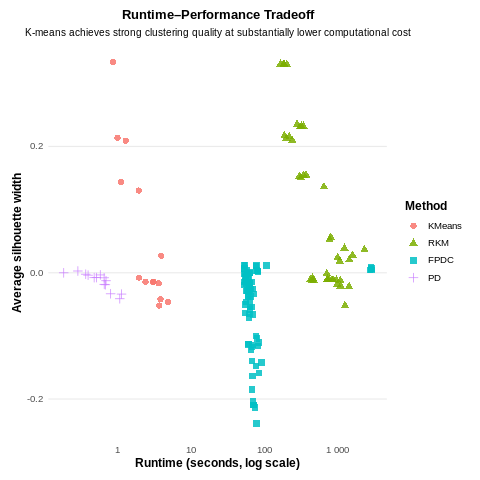

In [99]:
# Figure 3: Runtime vs silhouette tradeoff --- best practical comparison figure.
%%R
fig3_df <- plot_df_pub %>%
  filter(!is.na(runtime_sec), !is.na(silhouette))

p3 <- ggplot(fig3_df, aes(x = runtime_sec, y = silhouette, shape = method, color = method)) +
  geom_point(size = 2.6, alpha = 0.85) +
  scale_x_log10(labels = label_number()) +
  labs(
    title = "Runtime–Performance Tradeoff",
    subtitle = "K-means achieves strong clustering quality at substantially lower computational cost",
    x = "Runtime (seconds, log scale)",
    y = "Average silhouette width",
    color = "Method",
    shape = "Method"
  ) +
  theme_report()

print(p3)

ggsave(
  file.path(final_fig_dir, "figure3_runtime_vs_silhouette.png"),
  p3, width = 8.5, height = 5.5, dpi = 300
)

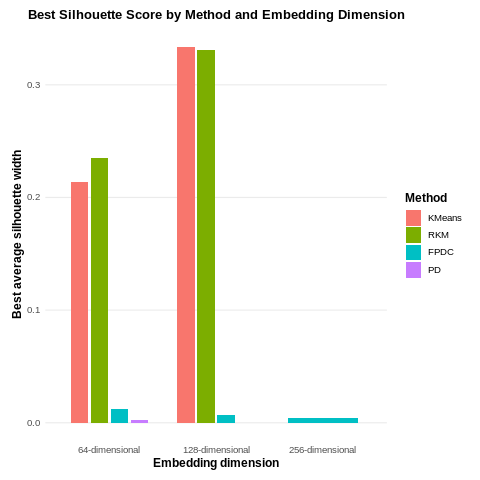

In [100]:
# Figure 4: Best silhouette by method and embedding
%%R
fig4_df <- plot_df_pub %>%
  filter(!is.na(silhouette)) %>%
  group_by(method, embedding_label) %>%
  summarise(
    best_silhouette = max(silhouette, na.rm = TRUE),
    .groups = "drop"
  )

p4 <- ggplot(fig4_df, aes(x = embedding_label, y = best_silhouette, fill = method)) +
  geom_col(position = position_dodge(width = 0.75), width = 0.65) +
  labs(
    title = "Best Silhouette Score by Method and Embedding Dimension",
    x = "Embedding dimension",
    y = "Best average silhouette width",
    fill = "Method"
  ) +
  theme_report()

print(p4)

ggsave(
  file.path(final_fig_dir, "figure4_best_silhouette_by_method_embedding.png"),
  p4, width = 8.5, height = 5.2, dpi = 300
)

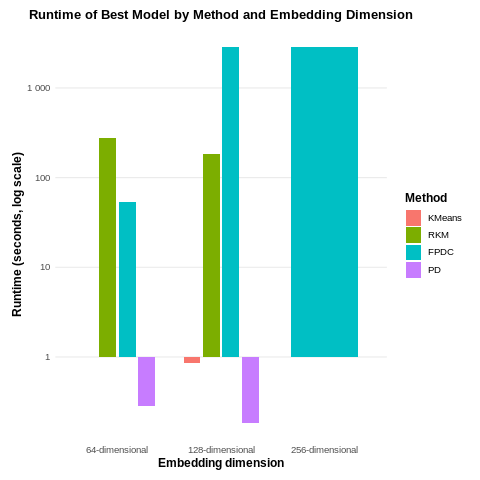

In [103]:
# Figure 5: Best runtime by method and embedding
%%R
fig5_df <- plot_df_pub %>%
  filter(!is.na(silhouette), !is.na(runtime_sec)) %>%
  group_by(method, embedding_label) %>%
  arrange(desc(silhouette), desc(ch), .by_group = TRUE) %>%
  slice(1) %>%
  ungroup()

p5 <- ggplot(fig5_df, aes(x = embedding_label, y = runtime_sec, fill = method)) +
  geom_col(position = position_dodge(width = 0.75), width = 0.65) +
  scale_y_log10(labels = label_number()) +
  labs(
    title = "Runtime of Best Model by Method and Embedding Dimension",
    x = "Embedding dimension",
    y = "Runtime (seconds, log scale)",
    fill = "Method"
  ) +
  theme_report()

print(p5)

ggsave(
  file.path(final_fig_dir, "figure5_best_runtime_by_method_embedding.png"),
  p5, width = 8.5, height = 5.2, dpi = 300
)

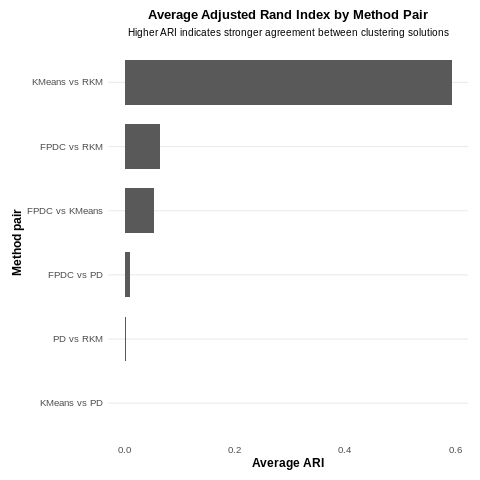

In [104]:
# Figure 6: ARI by method pair
%%R
ari_fig_df <- ari_df %>%
  filter(method_1 != method_2) %>%
  mutate(
    method_pair = paste(
      pmin(method_1, method_2),
      pmax(method_1, method_2),
      sep = " vs "
    )
  ) %>%
  group_by(method_pair) %>%
  summarise(
    avg_ari = mean(ari, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(avg_ari))

p6 <- ggplot(ari_fig_df, aes(x = reorder(method_pair, avg_ari), y = avg_ari)) +
  geom_col(width = 0.7) +
  coord_flip() +
  labs(
    title = "Average Adjusted Rand Index by Method Pair",
    subtitle = "Higher ARI indicates stronger agreement between clustering solutions",
    x = "Method pair",
    y = "Average ARI"
  ) +
  theme_report()

print(p6)

ggsave(
  file.path(final_fig_dir, "figure6_average_ari_by_method_pair.png"),
  p6, width = 8.5, height = 5.2, dpi = 300
)

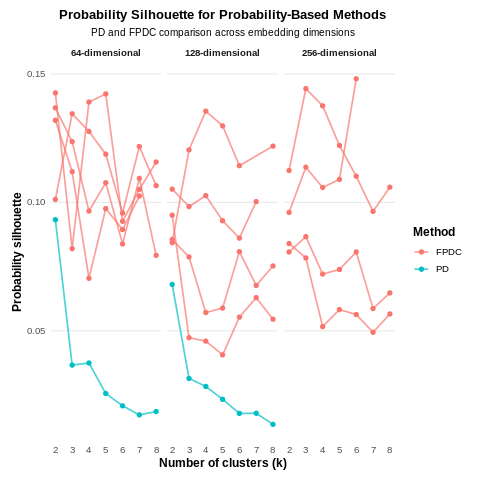

In [105]:
# Figure 7: FPDC/PD probability silhouette
%%R
fig7_df <- plot_df_pub %>%
  filter(method %in% c("PD", "FPDC"), !is.na(prob_silh))

p7 <- ggplot(fig7_df, aes(x = k, y = prob_silh, color = method, group = interaction(method, nf, nu))) +
  geom_line(alpha = 0.7, linewidth = 0.8) +
  geom_point(size = 1.8) +
  facet_wrap(~ embedding_label, nrow = 1) +
  scale_x_continuous(breaks = sort(unique(fig7_df$k))) +
  labs(
    title = "Probability Silhouette for Probability-Based Methods",
    subtitle = "PD and FPDC comparison across embedding dimensions",
    x = "Number of clusters (k)",
    y = "Probability silhouette",
    color = "Method"
  ) +
  theme_report()

print(p7)

ggsave(
  file.path(final_fig_dir, "figure7_probability_silhouette_pd_fpdc.png"),
  p7, width = 10, height = 4.8, dpi = 300
)

In [106]:
# 9. Report-ready summary table: best model per method and embedding

%%R
best_table <- plot_df_pub %>%
  filter(!is.na(silhouette)) %>%
  group_by(method, embedding_dim) %>%
  arrange(desc(silhouette), desc(ch), .by_group = TRUE) %>%
  slice(1) %>%
  ungroup() %>%
  transmute(
    Method = method,
    Embedding = embedding_dim,
    k = k,
    nf = nf,
    nu = nu,
    Runtime_sec = round(runtime_sec, 1),
    Silhouette = round(silhouette, 3),
    CH = round(ch, 2),
    ProbSilh = round(prob_silh, 3)
  ) %>%
  arrange(Embedding, Method)

print(best_table)

write.csv(
  best_table,
  file.path(final_fig_dir, "table_best_models_for_report.csv"),
  row.names = FALSE
)

# A tibble: 9 × 9
  Method Embedding     k    nf    nu Runtime_sec Silhouette     CH ProbSilh
  <fct>      <int> <int> <int> <int>       <dbl>      <dbl>  <dbl>    <dbl>
1 KMeans        64     2    NA    NA         1        0.214 132.     NA    
2 RKM           64     2     2    NA       279.       0.235 132.     NA    
3 FPDC          64     5     4    10        53.9      0.012  32.1     0.142
4 PD            64     2    NA    NA         0.3      0.003  10.1     0.093
5 KMeans       128     2    NA    NA         0.9      0.334 140.     NA    
6 RKM          128     2     4    NA       184.       0.331 140.     NA    
7 FPDC         128     2     2    10      2879.       0.007  52.8     0.084
8 PD           128     2    NA    NA         0.2      0       0.92    0.068
9 FPDC         256     2     3    10      2866.       0.004  28.5     0.096


In [107]:
%%R
# LaTeX/Quarto table output
library(knitr)

kable(
  best_table,
  format = "markdown",
  caption = "Best clustering result for each method and embedding dimension."
)



Table: Best clustering result for each method and embedding dimension.

|Method | Embedding|  k| nf| nu| Runtime_sec| Silhouette|     CH| ProbSilh|
|:------|---------:|--:|--:|--:|-----------:|----------:|------:|--------:|
|KMeans |        64|  2| NA| NA|         1.0|      0.214| 132.23|       NA|
|RKM    |        64|  2|  2| NA|       278.9|      0.235| 132.29|       NA|
|FPDC   |        64|  5|  4| 10|        53.9|      0.012|  32.12|    0.142|
|PD     |        64|  2| NA| NA|         0.3|      0.003|  10.14|    0.093|
|KMeans |       128|  2| NA| NA|         0.9|      0.334| 139.51|       NA|
|RKM    |       128|  2|  4| NA|       184.1|      0.331| 139.52|       NA|
|FPDC   |       128|  2|  2| 10|      2878.8|      0.007|  52.85|    0.084|
|PD     |       128|  2| NA| NA|         0.2|      0.000|   0.92|    0.068|
|FPDC   |       256|  2|  3| 10|      2865.7|      0.004|  28.50|    0.096|


Captions:
Figure 1. Average silhouette width across candidate values of k for K-means and PD clustering, stratified by embedding dimension.
Figure 3. Runtime–performance tradeoff across clustering methods. K-means achieves competitive or superior silhouette values at much lower computational cost.
Figure 4. Best silhouette score achieved by each method for each embedding dimension.
Figure 6. Average Adjusted Rand Index (ARI) between clustering methods, showing strongest agreement between K-means and RKM.


Main figures
Figure 1: Silhouette vs k
Figure 3: Runtime vs silhouette
Figure 4: Best silhouette by method and embedding
Figure 6: Average ARI by method pair
Main table
Best model per method and embedding
Optional appendix / extra figure
Figure 2: RKM silhouette vs k and nf
Figure 7: Probability silhouette for PD/FPDC

COMPARISONS

In [8]:
# 5. Install required R packages
%%R
packages <- c(
  "readr",
  "dplyr",
  "ggplot2",
  "cluster",
  "factoextra",
  "clusterCrit",
  "FPDclustering",
  "clustrd"
)

installed <- rownames(installed.packages())
to_install <- setdiff(packages, installed)

if (length(to_install) > 0) {
  install.packages(to_install, repos = "https://cloud.r-project.org")
}

lapply(packages, library, character.only = TRUE)

[[1]]
 [1] "mclust"    "ggplot2"   "purrr"     "stringr"   "tidyr"     "dplyr"    
 [7] "readr"     "tools"     "stats"     "graphics"  "grDevices" "utils"    
[13] "datasets"  "methods"   "base"     

[[2]]
 [1] "mclust"    "ggplot2"   "purrr"     "stringr"   "tidyr"     "dplyr"    
 [7] "readr"     "tools"     "stats"     "graphics"  "grDevices" "utils"    
[13] "datasets"  "methods"   "base"     

[[3]]
 [1] "mclust"    "ggplot2"   "purrr"     "stringr"   "tidyr"     "dplyr"    
 [7] "readr"     "tools"     "stats"     "graphics"  "grDevices" "utils"    
[13] "datasets"  "methods"   "base"     

[[4]]
 [1] "cluster"   "mclust"    "ggplot2"   "purrr"     "stringr"   "tidyr"    
 [7] "dplyr"     "readr"     "tools"     "stats"     "graphics"  "grDevices"
[13] "utils"     "datasets"  "methods"   "base"     

[[5]]
 [1] "factoextra" "cluster"    "mclust"     "ggplot2"    "purrr"     
 [6] "stringr"    "tidyr"      "dplyr"      "readr"      "tools"     
[11] "stats"      "graphics"   "gr

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘R.methodsS3’, ‘R.oo’, ‘R.utils’, ‘proxy’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘lazyeval’, ‘R.cache’, ‘e1071’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘crosstalk’, ‘estimability’, ‘numDeriv’, ‘corrplot’, ‘styler’, ‘classInt’, ‘labelled’, ‘patchwork’, ‘RcppEigen’, ‘modeltools’, ‘DEoptimR’, ‘viridis’, ‘car’, ‘DT’, ‘ellipse’, ‘emmeans’, ‘flashClust’, ‘leaps’, ‘multcompView’, ‘scatterplot3d’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘rstatix’, ‘prettyGraphs’, ‘combinat’, ‘questionr’, ‘ggstats’, ‘RSpectra’, ‘flexmix’, ‘prabclus’, ‘diptest’, ‘robustbase’, ‘kernlab’, ‘dendextend’, ‘FactoMineR’, ‘ggpubr’, ‘ggrepel’, ‘ThreeWay’, ‘mvtnorm’, ‘ExPosition’, ‘rootSolve’, ‘klaR’

In [ ]:
%%R
library(readr)
library(dplyr)
library(cluster)
library(clusterCrit)
library(clustrd)
library(FPDclustering)
library(tidyr)

set.seed(42)

# --------------------------------------------------
# 1. Paths
# --------------------------------------------------
base_repo <- "/content/math252-project"
drive_out <- "/content/drive/MyDrive/math252-project-colab-output"

dir.create(file.path(drive_out, "output"), recursive = TRUE, showWarnings = FALSE)
dir.create(file.path(drive_out, "output", "benchmark_cache"), recursive = TRUE, showWarnings = FALSE)
dir.create(file.path(drive_out, "output", "benchmark_results"), recursive = TRUE, showWarnings = FALSE)

all_embedding_paths <- c(
  # file.path(base_repo, "output", "embeddings", "user_embeddings_64.csv"),
  # file.path(base_repo, "output", "embeddings", "user_embeddings_128.csv"),
  file.path(base_repo, "output", "embeddings", "user_embeddings_256.csv")
)

# --------------------------------------------------
# 2. Mode switch
# --------------------------------------------------
run_mode <- "full"   # change to "full" later

if (run_mode == "test") {
  embedding_paths <- all_embedding_paths[1]
  k_range <- 2:4
  nf_range <- 4:5   # only for RKM
} else if (run_mode == "full") {
  embedding_paths <- all_embedding_paths
  k_range <- 2:8
  nf_range <- 2:5
} else {
  stop("run_mode must be 'test' or 'full'")
}

cat("Run mode:", run_mode, "\n")
print(embedding_paths)
cat("k range:", paste(range(k_range), collapse = " to "), "\n")
cat("nf range (RKM only):", paste(range(nf_range), collapse = " to "), "\n\n")

# --------------------------------------------------
# 3. Helper functions
# --------------------------------------------------

safe_ch <- function(x, labels) {
  out <- tryCatch(
    intCriteria(
      traj = x,
      part = as.integer(labels),
      crit = "Calinski_Harabasz"
    )$calinski_harabasz,
    error = function(e) NA_real_
  )
  out
}

safe_sil <- function(labels, dmat) {
  out <- tryCatch(
    mean(silhouette(labels, dmat)[, 3]),
    error = function(e) NA_real_
  )
  out
}

# --------------------------------------------------
# 4. Main loop
# --------------------------------------------------
all_method_summaries <- list()
all_best_models <- list()

overall_start <- Sys.time()

for (embedding_path in embedding_paths) {

  if (!file.exists(embedding_path)) {
    cat("Missing file:", embedding_path, "\n")
    next
  }

  embedding_tag <- tools::file_path_sans_ext(basename(embedding_path))
  cat("\n========================================\n")
  cat("Processing embedding:", embedding_tag, "\n")
  cat("========================================\n")

  embeddings <- read_csv(embedding_path, show_col_types = FALSE)
  user_ids <- embeddings[[1]]
  x <- scale(as.matrix(embeddings[, -1]))
  dmat <- dist(x)

  # --------------------------------------
  # KMEANS
  # --------------------------------------
  kmeans_results <- list()

  for (k_val in k_range) {
    cache_file <- file.path(
      drive_out, "output", "benchmark_cache",
      paste0("kmeans_", embedding_tag, "_k", k_val, ".rds")
    )

    if (file.exists(cache_file)) {
      res <- readRDS(cache_file)
    } else {
      t0 <- Sys.time()

      model <- kmeans(
        x,
        centers = k_val,
        nstart = 25,
        iter.max = 100,
        algorithm = "MacQueen"
      )

      runtime_i <- as.numeric(difftime(Sys.time(), t0, units = "secs"))
      sil_val <- safe_sil(model$cluster, dmat)
      ch_val <- safe_ch(x, model$cluster)

      res <- list(
        Method = "KMeans",
        embedding = embedding_tag,
        k = k_val,
        nf = NA,
        runtime_sec = runtime_i,
        Silhouette = sil_val,
        CH = ch_val,
        ProbSilh = NA_real_,
        labels = model$cluster,
        model = model
      )

      saveRDS(res, cache_file)
    }

    kmeans_results[[length(kmeans_results) + 1]] <- res
    cat(sprintf("KMeans | %s | k=%d | time=%.1f | Sil=%.5f | CH=%.5f\n",
                embedding_tag, k_val, res$runtime_sec, res$Silhouette, res$CH))
  }

  kmeans_df <- bind_rows(lapply(kmeans_results, function(z) {
    data.frame(
      Method = z$Method,
      embedding = z$embedding,
      k = z$k,
      nf = z$nf,
      runtime_sec = z$runtime_sec,
      Silhouette = z$Silhouette,
      CH = z$CH,
      ProbSilh = z$ProbSilh
    )
  }))

  valid_km <- which(!is.na(kmeans_df$Silhouette))
  best_km_idx <- valid_km[order(-kmeans_df$Silhouette[valid_km], -kmeans_df$CH[valid_km])[1]]
  best_km <- kmeans_results[[best_km_idx]]

  # --------------------------------------
  # PD
  # --------------------------------------
  pd_results <- list()

  for (k_val in k_range) {
    cache_file <- file.path(
      drive_out, "output", "benchmark_cache",
      paste0("pd_", embedding_tag, "_k", k_val, ".rds")
    )

    if (file.exists(cache_file)) {
      res <- readRDS(cache_file)
    } else {
      t0 <- Sys.time()

      model <- tryCatch(
        PDC(x, k = k_val),
        error = function(e) NULL
      )

      runtime_i <- as.numeric(difftime(Sys.time(), t0, units = "secs"))

      if (is.null(model)) {
        res <- list(
          Method = "PD",
          embedding = embedding_tag,
          k = k_val,
          nf = NA,
          runtime_sec = runtime_i,
          Silhouette = NA_real_,
          CH = NA_real_,
          ProbSilh = NA_real_,
          labels = NULL,
          model = NULL
        )
      } else {
        labels <- model$label
        sil_val <- safe_sil(labels, dmat)
        ch_val <- safe_ch(x, labels)
        prob_val <- tryCatch(Silh(model$probability), error = function(e) NA_real_)

        res <- list(
          Method = "PD",
          embedding = embedding_tag,
          k = k_val,
          nf = NA,
          runtime_sec = runtime_i,
          Silhouette = sil_val,
          CH = ch_val,
          ProbSilh = prob_val,
          labels = labels,
          model = model
        )
      }

      saveRDS(res, cache_file)
    }

    pd_results[[length(pd_results) + 1]] <- res
    cat(sprintf("PD     | %s | k=%d | time=%.1f | Sil=%.5f | CH=%.5f | Prob=%.5f\n",
                embedding_tag, k_val, res$runtime_sec, res$Silhouette, res$CH, res$ProbSilh))
  }

  pd_df <- bind_rows(lapply(pd_results, function(z) {
    data.frame(
      Method = z$Method,
      embedding = z$embedding,
      k = z$k,
      nf = z$nf,
      runtime_sec = z$runtime_sec,
      Silhouette = z$Silhouette,
      CH = z$CH,
      ProbSilh = z$ProbSilh
    )
  }))

  valid_pd <- which(!is.na(pd_df$Silhouette))
  best_pd_idx <- valid_pd[order(-pd_df$Silhouette[valid_pd], -pd_df$CH[valid_pd])[1]]
  best_pd <- pd_results[[best_pd_idx]]

  # --------------------------------------
  # RKM
  # --------------------------------------
  rkm_results <- list()

  for (k_val in k_range) {
    for (nf_val in nf_range) {
      cache_file <- file.path(
        drive_out, "output", "benchmark_cache",
        paste0("rkm_", embedding_tag, "_k", k_val, "_nf", nf_val, ".rds")
      )

      if (file.exists(cache_file)) {
        res <- readRDS(cache_file)
      } else {
        t0 <- Sys.time()

        model <- tryCatch(
          cluspca(
            x,
            nclus = k_val,
            ndim = nf_val,
            method = "RKM",
            rotation = "varimax"
          ),
          error = function(e) NULL
        )

        runtime_i <- as.numeric(difftime(Sys.time(), t0, units = "secs"))

        if (is.null(model)) {
          res <- list(
            Method = "RKM",
            embedding = embedding_tag,
            k = k_val,
            nf = nf_val,
            runtime_sec = runtime_i,
            Silhouette = NA_real_,
            CH = NA_real_,
            ProbSilh = NA_real_,
            labels = NULL,
            model = NULL
          )
        } else {
          labels <- model$cluster
          sil_val <- safe_sil(labels, dmat)
          ch_val <- safe_ch(x, labels)

          res <- list(
            Method = "RKM",
            embedding = embedding_tag,
            k = k_val,
            nf = nf_val,
            runtime_sec = runtime_i,
            Silhouette = sil_val,
            CH = ch_val,
            ProbSilh = NA_real_,
            labels = labels,
            model = model
          )
        }

        saveRDS(res, cache_file)
      }

      rkm_results[[length(rkm_results) + 1]] <- res
      cat(sprintf("RKM    | %s | k=%d nf=%d | time=%.1f | Sil=%.5f | CH=%.5f\n",
                  embedding_tag, k_val, nf_val, res$runtime_sec, res$Silhouette, res$CH))
    }
  }

  rkm_df <- bind_rows(lapply(rkm_results, function(z) {
    data.frame(
      Method = z$Method,
      embedding = z$embedding,
      k = z$k,
      nf = z$nf,
      runtime_sec = z$runtime_sec,
      Silhouette = z$Silhouette,
      CH = z$CH,
      ProbSilh = z$ProbSilh
    )
  }))

  valid_rkm <- which(!is.na(rkm_df$Silhouette))
  best_rkm_idx <- valid_rkm[order(-rkm_df$Silhouette[valid_rkm], -rkm_df$CH[valid_rkm])[1]]
  best_rkm <- rkm_results[[best_rkm_idx]]

  # --------------------------------------
  # Save per-embedding combined results
  # --------------------------------------
  combined_df <- bind_rows(kmeans_df, pd_df, rkm_df)

  write.csv(
    combined_df,
    file = file.path(
      drive_out, "output", "benchmark_results",
      paste0("benchmark_results_", embedding_tag, ".csv")
    ),
    row.names = FALSE
  )

  best_df <- bind_rows(
    data.frame(
      Method = "KMeans",
      embedding = embedding_tag,
      k = best_km$k,
      nf = best_km$nf,
      runtime_sec = best_km$runtime_sec,
      Silhouette = best_km$Silhouette,
      CH = best_km$CH,
      ProbSilh = best_km$ProbSilh
    ),
    data.frame(
      Method = "PD",
      embedding = embedding_tag,
      k = best_pd$k,
      nf = best_pd$nf,
      runtime_sec = best_pd$runtime_sec,
      Silhouette = best_pd$Silhouette,
      CH = best_pd$CH,
      ProbSilh = best_pd$ProbSilh
    ),
    data.frame(
      Method = "RKM",
      embedding = embedding_tag,
      k = best_rkm$k,
      nf = best_rkm$nf,
      runtime_sec = best_rkm$runtime_sec,
      Silhouette = best_rkm$Silhouette,
      CH = best_rkm$CH,
      ProbSilh = best_rkm$ProbSilh
    )
  )

  all_method_summaries[[embedding_tag]] <- best_df
  all_best_models[[paste0(embedding_tag, "_KMeans")]] <- best_km
  all_best_models[[paste0(embedding_tag, "_PD")]] <- best_pd
  all_best_models[[paste0(embedding_tag, "_RKM")]] <- best_rkm
}

# --------------------------------------------------
# 5. Save final summary table
# --------------------------------------------------
summary_df <- bind_rows(all_method_summaries)

write.csv(
  summary_df,
  file = file.path(
    drive_out, "output", "benchmark_results",
    "benchmark_best_models_summary.csv"
  ),
  row.names = FALSE
)

cat("\n========================================\n")
cat("FINAL BEST-MODEL SUMMARY\n")
cat("========================================\n")
print(summary_df)

cat("\nAll done.\n")
cat("Total runtime:",
    round(as.numeric(difftime(Sys.time(), overall_start, units = "mins")), 2),
    "minutes\n")
cat("Saved files in:\n", file.path(drive_out, "output", "benchmark_results"), "\n")

Run mode: full 
[1] "/content/math252-project/output/embeddings/user_embeddings_256.csv"
k range: 2 to 8 
nf range (RKM only): 2 to 5 


Processing embedding: user_embeddings_256 
KMeans | user_embeddings_256 | k=2 | time=2.7 | Sil=0.28762 | CH=111.23614
KMeans | user_embeddings_256 | k=3 | time=2.8 | Sil=0.17193 | CH=91.74015
KMeans | user_embeddings_256 | k=4 | time=3.3 | Sil=0.03804 | CH=74.66044
KMeans | user_embeddings_256 | k=5 | time=4.6 | Sil=0.06711 | CH=64.83231
KMeans | user_embeddings_256 | k=6 | time=6.8 | Sil=0.13005 | CH=55.50620
KMeans | user_embeddings_256 | k=7 | time=7.4 | Sil=0.07804 | CH=51.32519
KMeans | user_embeddings_256 | k=8 | time=8.9 | Sil=-0.02719 | CH=44.89592
PD     | user_embeddings_256 | k=2 | time=0.3 | Sil=-0.00002 | CH=1.06609 | Prob=0.06223
PD     | user_embeddings_256 | k=3 | time=0.9 | Sil=-0.00369 | CH=1.00114 | Prob=0.02902
PD     | user_embeddings_256 | k=4 | time=0.6 | Sil=-0.00521 | CH=0.92546 | Prob=0.01761
PD     | user_embeddings_256 | k=